# 04 — Cell type annotation
Input: integrated object (RPCA), 15 clusters at resolution 0.3.
Paper: cluster phenotypes predicted with BlueprintEncode (celldex) via SingleR,
verified by lineage markers. Goal: identify CD4 T cells for sub-clustering (Fig 5a).

## Step 10.1 — Setup and load the integrated object

In [1]:
suppressPackageStartupMessages({
  library(Seurat); library(tidyverse); library(patchwork)
  library(SingleR); library(celldex)
})
proj <- "/mnt/d/project3_IFN-I"
set.seed(42)
options(future.globals.maxSize = Inf)

m   <- "rpca"
obj <- readRDS(file.path(proj, "results/objects", paste0("03_integrated_", m, ".rds")))
Idents(obj) <- paste0("clusters_", m)
obj

An object of class Seurat 
36601 features across 90502 samples within 1 assay 
Active assay: RNA (36601 features, 2000 variable features)
 2 layers present: data, counts
 4 dimensional reductions calculated: pca, umap.unintegrated, integrated.rpca, umap.rpca

## Step 10.2 — SingleR annotation per cluster (BlueprintEncode)

In [2]:
ref  <- BlueprintEncodeData()
expr <- LayerData(obj, assay = "RNA", layer = "data")

sr_main <- SingleR(test = expr, ref = ref, labels = ref$label.main, clusters = Idents(obj))
sr_fine <- SingleR(test = expr, ref = ref, labels = ref$label.fine, clusters = Idents(obj))
rm(expr); invisible(gc())

singler_tab <- tibble(cluster    = rownames(sr_main),
                      n_cells    = as.integer(table(Idents(obj))[rownames(sr_main)]),
                      label_main = sr_main$pruned.labels,
                      label_fine = sr_fine$pruned.labels)
singler_tab
write_csv(singler_tab, file.path(proj, "results/tables", paste0("04_singler_clusters_", m, ".csv")))

cluster,n_cells,label_main,label_fine
<chr>,<int>,<chr>,<chr>
0,24806,Monocytes,Monocytes
1,12881,CD8+ T-cells,CD8+ Tem
2,12787,CD4+ T-cells,CD4+ T-cells
3,9755,CD4+ T-cells,CD4+ T-cells
4,8626,B-cells,naive B-cells
5,8383,NK cells,NK cells
6,3505,Monocytes,Monocytes
7,2721,Monocytes,Monocytes
8,2195,CD4+ T-cells,CD4+ T-cells


## Step 10.3 — Canonical marker dot plot

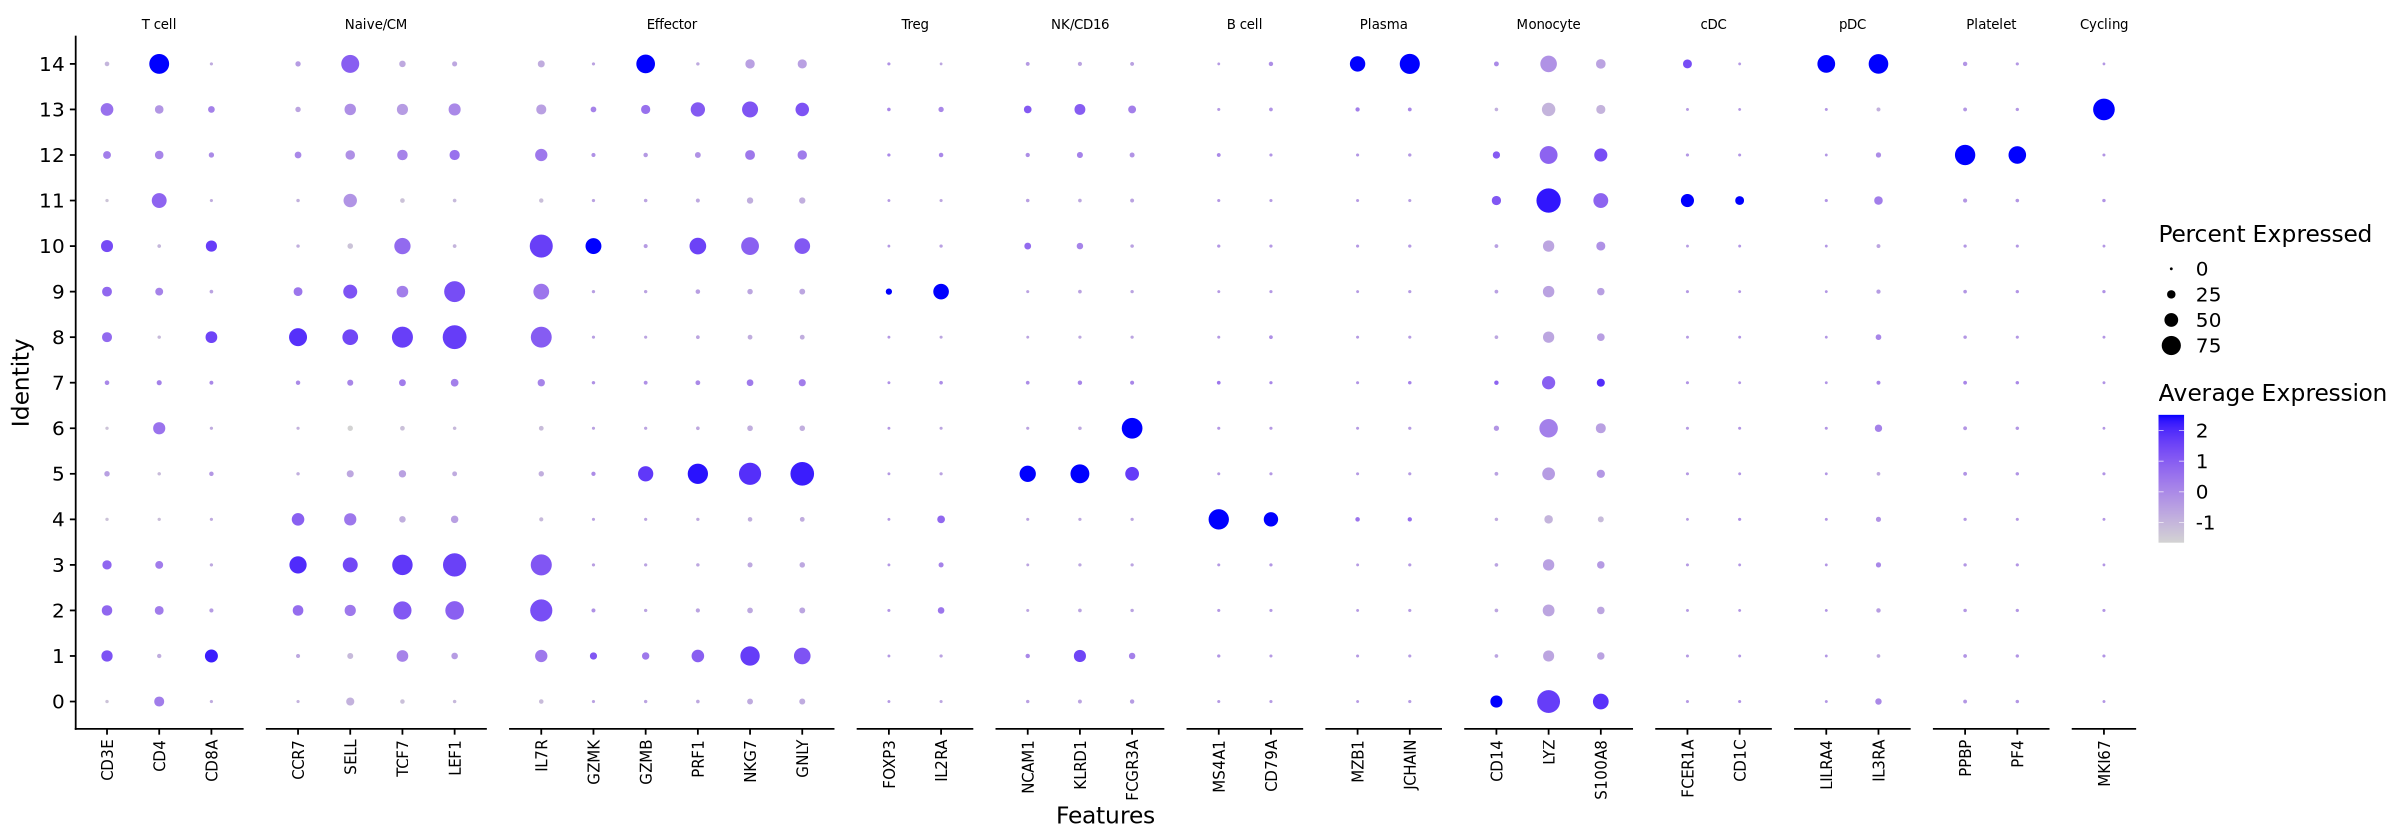

In [3]:
marker_list <- list(
  "T cell"    = c("CD3E", "CD4", "CD8A"),
  "Naive/CM"  = c("CCR7", "SELL", "TCF7", "LEF1"),
  "Effector"  = c("IL7R", "GZMK", "GZMB", "PRF1", "NKG7", "GNLY"),
  "Treg"      = c("FOXP3", "IL2RA"),
  "NK/CD16"   = c("NCAM1", "KLRD1", "FCGR3A"),
  "B cell"    = c("MS4A1", "CD79A"),
  "Plasma"    = c("MZB1", "JCHAIN"),
  "Monocyte"  = c("CD14", "LYZ", "S100A8"),
  "cDC"       = c("FCER1A", "CD1C"),
  "pDC"       = c("LILRA4", "IL3RA"),
  "Platelet"  = c("PPBP", "PF4"),
  "Cycling"   = c("MKI67")
)

options(repr.plot.width = 20, repr.plot.height = 7)
dp <- DotPlot(obj, features = marker_list) +
  theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5, size = 9),
        strip.text.x = element_text(size = 8))
dp
ggsave(file.path(proj, "figures/trackB", paste0("04_marker_dotplot_", m, ".png")),
       dp, width = 20, height = 7, dpi = 150)

In [ ]:
## Step 10.4 — Top marker genes per cluster

In [4]:
all_markers <- FindAllMarkers(obj, only.pos = TRUE, min.pct = 0.25, logfc.threshold = 0.5,
                              max.cells.per.ident = 500, verbose = FALSE)
write_csv(all_markers, file.path(proj, "results/tables", paste0("04_cluster_markers_", m, ".csv")))

top_markers <- all_markers |>
  group_by(cluster) |>
  slice_max(avg_log2FC, n = 8) |>
  summarise(top_genes = paste(gene, collapse = ", "))
top_markers

For a (much!) faster implementation of the Wilcoxon Rank Sum Test,
(default method for FindMarkers) please install the presto package
--------------------------------------------
install.packages('devtools')
devtools::install_github('immunogenomics/presto')
--------------------------------------------
After installation of presto, Seurat will automatically use the more 
efficient implementation (no further action necessary).
This message will be shown once per session



cluster,top_genes
<fct>,<chr>
0,"VCAN-AS1, SDC2, CXCL8, NRG1, CYP27A1, FCAR, LIN7A, LINC00937"
1,"TRGC2, CD8A, GZMH, CD8B, MSC-AS1, CCL5, PZP, A2M"
2,"ST8SIA1, EPHA4, FAAH2, GATA3, ANK3, INPP4B, AP3M2, CMTM8"
3,"LEF1-AS1, AK5, CHRM3-AS2, EDA, AL109930.1, AC139720.1, TSHZ2, FHIT"
4,"MROH9, KLHL14, GABRB2, BX284613.2, AL079338.1, ROR1, COL19A1, AP002075.1"
5,"LINGO2, BNC2, RNF165, NCAM1, SH2D1B, KLRF1, NCR1, IL18RAP"
6,"AC104809.2, AC020651.2, LINC02085, CDKN1C, FMNL2, CCDC26, AC092546.1, TCF7L2"
7,"ATP5F1E, UBA52, SH3BGRL3, RPS25, RPL27, ITGAX, RPL36, GABARAP"
8,"NRCAM, AL590006.1, PTPRK, LINC02446, NELL2, LRRN3, CD8B, LEF1-AS1"


## Step 10.5 — QC metrics by cluster (check cluster 7)

In [5]:
obj[["percent.ribo"]] <- PercentageFeatureSet(obj, pattern = "^RP[SL]")

qc_by_cluster <- obj@meta.data |>
  group_by(cluster = .data[[paste0("clusters_", m)]]) |>
  summarise(n_cells      = n(),
            median_genes = median(nFeature_RNA),
            median_umi   = median(nCount_RNA),
            median_mt    = round(median(percent.mt), 2),
            median_ribo  = round(median(percent.ribo), 2),
            .groups = "drop")
qc_by_cluster
write_csv(qc_by_cluster, file.path(proj, "results/tables", paste0("04_qc_by_cluster_", m, ".csv")))

cluster,n_cells,median_genes,median_umi,median_mt,median_ribo
<fct>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
0,24806,2243.0,5360.0,6.84,1.15
1,12881,1853.0,3593.0,5.78,4.35
2,12787,1940.0,4096.0,6.02,3.06
3,9755,1659.0,3323.0,6.82,3.41
4,8626,1894.0,4247.0,5.78,2.24
5,8383,1877.0,3628.0,5.96,2.87
6,3505,2530.0,6407.0,7.85,1.28
7,2721,749.0,1050.0,6.85,2.53
8,2195,1796.0,3770.0,8.54,3.25


## Step 10.6 — Assign cell type labels

In [6]:
labels <- c("0"  = "CD14 monocytes",  "1"  = "CD8 effector memory",
            "2"  = "CD4 memory",      "3"  = "CD4 naive/CM",
            "4"  = "B cells",         "5"  = "NK cells",
            "6"  = "CD16 monocytes",  "7"  = "Low quality",
            "8"  = "CD8 naive",       "9"  = "Treg",
            "10" = "MAIT",            "11" = "cDC2",
            "12" = "Platelets",       "13" = "Proliferating",
            "14" = "pDC")

cl <- as.character(obj[[paste0("clusters_", m)]][[1]])
obj$celltype <- unname(labels[cl])
table(obj$celltype, useNA = "ifany")


            B cells      CD14 monocytes      CD16 monocytes          CD4 memory 
               8626               24806                3505               12787 
       CD4 naive/CM CD8 effector memory           CD8 naive                cDC2 
               9755               12881                2195                 900 
        Low quality                MAIT            NK cells                 pDC 
               2721                1217                8383                  92 
          Platelets       Proliferating                Treg 
                453                 268                1913 

## Step 10.7 — Labelled UMAP

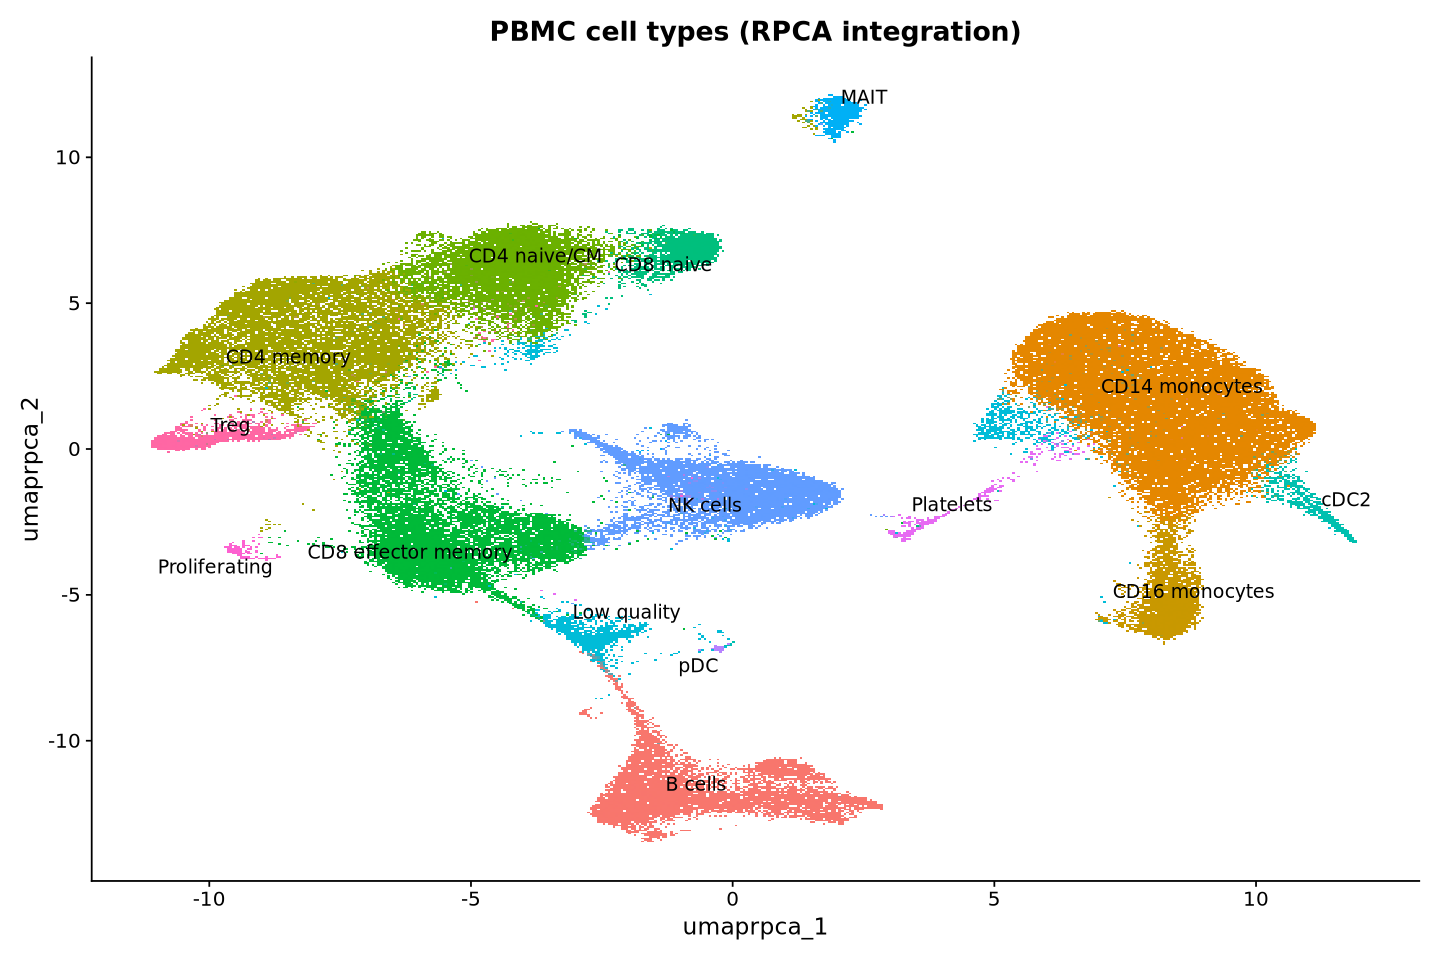

In [7]:
options(repr.plot.width = 12, repr.plot.height = 8)
p_ct <- DimPlot(obj, reduction = paste0("umap.", m), group.by = "celltype",
                label = TRUE, repel = TRUE, raster = TRUE) +
  NoLegend() + ggtitle("PBMC cell types (RPCA integration)")
p_ct
ggsave(file.path(proj, "figures/trackB", paste0("04_umap_celltypes_", m, ".png")),
       p_ct, width = 12, height = 8, dpi = 150)

## Step 10.8 — Cell type counts per sample

In [8]:
ct_by_sample <- table(obj$celltype, obj$sample)
ct_by_sample
write.csv(as.data.frame.matrix(ct_by_sample),
          file.path(proj, "results/tables", paste0("04_celltype_by_sample_", m, ".csv")))

                     
                       HD1  HD2   P1   P2   P3   P4   P5   P6   P7   P8
  B cells              420  307  353  403   22 4959  377  439  227 1119
  CD14 monocytes      1414 2123 3748 3196 5253 1642  199 3188 1931 2112
  CD16 monocytes        73   99  682  797  704  140   23  368  320  299
  CD4 memory          1595 1190 1216 2522 1905  669  485 1101 1318  786
  CD4 naive/CM        1383  240  298 1570  956  862  750  663 1350 1683
  CD8 effector memory 1027 5036 1382 1295  590  167  432 1171 1131  650
  CD8 naive            397   38   39  346  396   99  136  116   70  558
  cDC2                  43   43   73   73  288   41   14  116  115   94
  Low quality          157  266  343 1060  176  197   59   63  317   83
  MAIT                  53   44   25   92   79   58   63   35  171  597
  NK cells             371 1287  767  651  889  630  159 1580 1375  674
  pDC                    6   16    6    5   11    1    3    1   43    0
  Platelets             30   71   58   31 

## Step 10.9 — Save the annotated object

In [9]:
saveRDS(obj, file.path(proj, "results/objects", paste0("04_annotated_", m, ".rds")), compress = FALSE)

### Annotation summary
- SingleR (BlueprintEncode, cluster level) + canonical markers + top cluster markers.
- Data are single-nucleus RNA (10x Multiome): top markers include many lncRNAs/long genes.
- SingleR corrections: cluster 8 = CD8 naive (not CD4); 11 = cDC2, 12 = platelets (not monocytes);
  14 = pDC (no pDC category in BlueprintEncode); 10 = MAIT (SLC4A10, GZMK).
- Cluster 7 excluded as low quality: median 749 genes / 1,050 UMIs (~1/3 of other clusters),
  top markers ribosomal/housekeeping; 2,721 cells (3%), P2-enriched. Deviation from paper.
- CD4 T compartment for sub-clustering: clusters 2 (memory), 3 (naive/CM), 9 (Treg).
  Possible CD4 TEMRA cells within cluster 1 (CD8 effector) — to check.

  - CD4 cells per sample (memory + naive/CM + Treg): HD1 3,096; HD2 1,555; P1 1,748; P2 4,517;
  P3 3,140; P4 1,672; P5 1,288; P6 1,909; P7 2,907; P8 2,623.
  High IRC 11,077; low IRC 8,727; HD 4,651.
- P2 contributes 41% of high-IRC CD4 cells -> cell-level DE (paper) is weighted towards P2;
  plan pseudobulk DE (patient-level) as a robustness check.
- Other compositional differences: HD2 large CD8 Tem pool; P4 B-rich, P3 B-poor; P8 MAIT-rich.